# **Analyzing Economic Trends Through Popular Music**

## **Introduction**
This project explores the relationship between economic indicators and music trends over the period of 2010-2023. The goal is to analyze whether economic conditions - such as GDP growth, inflation, and unemployment - have any correlation with the characteristics of popular music.  

## **Datasets Used**
1. **World Bank - World Development Indicators:** Contains key economic data such as GDP growth rate, inflation rate, and unemployment rates.  
2. **Spotify Streaming Data:** Provides insights into popular music trends, including song features like tempo, valence (happiness), and danceability.  

## **Tools & Techniques**
- **Python Libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn`  
- **Data Cleaning & Preprocessing:** Handling missing values, filtering relevant data, and merging datasets.  
- **Visualization:** Creating line plots, bar charts, and scatter plots to identify patterns.  

Through this analysis, we aim to understand if economic downturns or booms influence the mood and characteristics of popular music. 

## 1. Import Libraries and Load Data
We begin by importing essential libraries and reading the datasets into Pandas DataFrames.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
spotify_df = pd.read_csv("spotify_data.csv")
world_bank_df = pd.read_csv("world_bank_data.csv")

## 2. Preprocessing Data

### Spotify Data
We clean and format the Spotify data by:
- Standardizing column names,
- Extracting the year from the release date,
- Dropping missing values,
- Grouping by year to calculate the **average number of streams** per year.

This gives us a single metric—**average_streams**—to represent music popularity trends over time.

### World Bank Data
We prepare the World Bank data similarly by:
- Cleaning column names,
- Ensuring the `year` column is in integer format.

This dataset includes key economic indicators like **GDP growth**, **inflation**, and **unemployment**, which we’ll later compare with streaming trends.

In [3]:
spotify_df.columns

Index(['Unnamed: 0', 'Artist and Title', 'Artist', 'Streams', 'Daily', 'year',
       'main_genre', 'genres', 'first_genre', 'second_genre', 'third_genre'],
      dtype='object')

In [4]:
world_bank_df.columns

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code',
       '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]',
       '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]',
       '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]',
       '2022 [YR2022]', '2023 [YR2023]'],
      dtype='object')

In [5]:
# Clean column names
spotify_df.columns = spotify_df.columns.str.strip().str.lower().str.replace(" ", "_")

# Drop rows with missing year or streams
spotify_df.dropna(subset=['year', 'streams'], inplace=True)

# Ensure year is integer
spotify_df['year'] = spotify_df['year'].astype(int)

# Create a clean subset
spotify_clean = spotify_df[['artist', 'artist_and_title', 'streams', 'year']].copy()

# Calculate average streams per year
spotify_yearly = spotify_clean.groupby('year')['streams'].mean().reset_index()
spotify_yearly.rename(columns={'streams': 'average_streams'}, inplace=True)

# Preview
spotify_yearly.head()

,year,average_streams
0,2010,3.265902e+08
1,2011,3.534541e+08
2,2012,3.562315e+08
3,2013,3.438661e+08
4,2014,3.365015e+08


In [6]:
# Clean column names first
world_bank_df.columns = world_bank_df.columns.str.strip().str.lower().str.replace(" ", "_")

# Melt the DataFrame to long-form
world_bank_long = pd.melt(
    world_bank_df,
    id_vars=['country_name', 'country_code', 'series_name', 'series_code'],
    var_name='year',
    value_name='value'
)

# Clean the 'year' column to remove brackets and convert to int
world_bank_long['year'] = world_bank_long['year'].str.extract(r'(\d{4})').astype(int)

# Preview the reshaped DataFrame
world_bank_long.head()

,country_name,country_code,series_name,series_code,year,value
0,World,WLD,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2010,4.517430
1,World,WLD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2010,3.326345
2,World,WLD,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,2010,6.286335
3,NaN,NaN,NaN,NaN,2010,NaN
4,NaN,NaN,NaN,NaN,2010,NaN


## 3. Spotify Specific Visualisations

### Boxplot: Streams Distribution by Year

This boxplot displays the spread and distribution of song streams across different years. It helps identify trends, outliers, and variations in listening patterns over time.

### Boxplot: Streams by Genre

This plot compares the number of streams across different music genres. It provides insight into which genres are more popular or receive higher streaming volumes.

In [7]:
print(spotify_df.columns.tolist())

['unnamed:_0', 'artist_and_title', 'artist', 'streams', 'daily', 'year', 'main_genre', 'genres', 'first_genre', 'second_genre', 'third_genre']


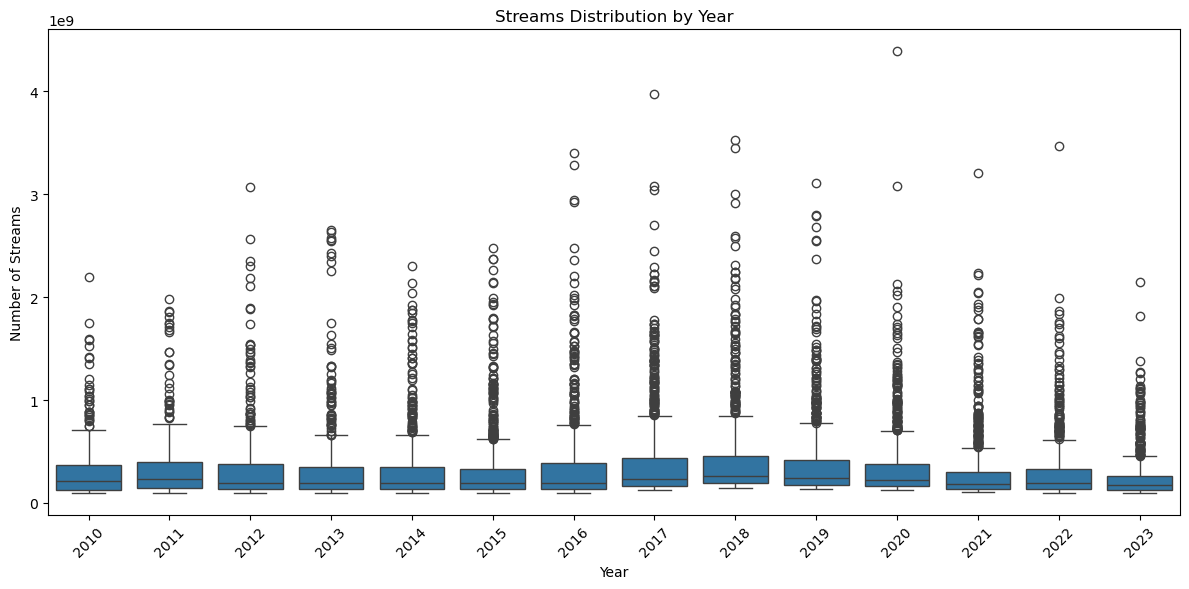

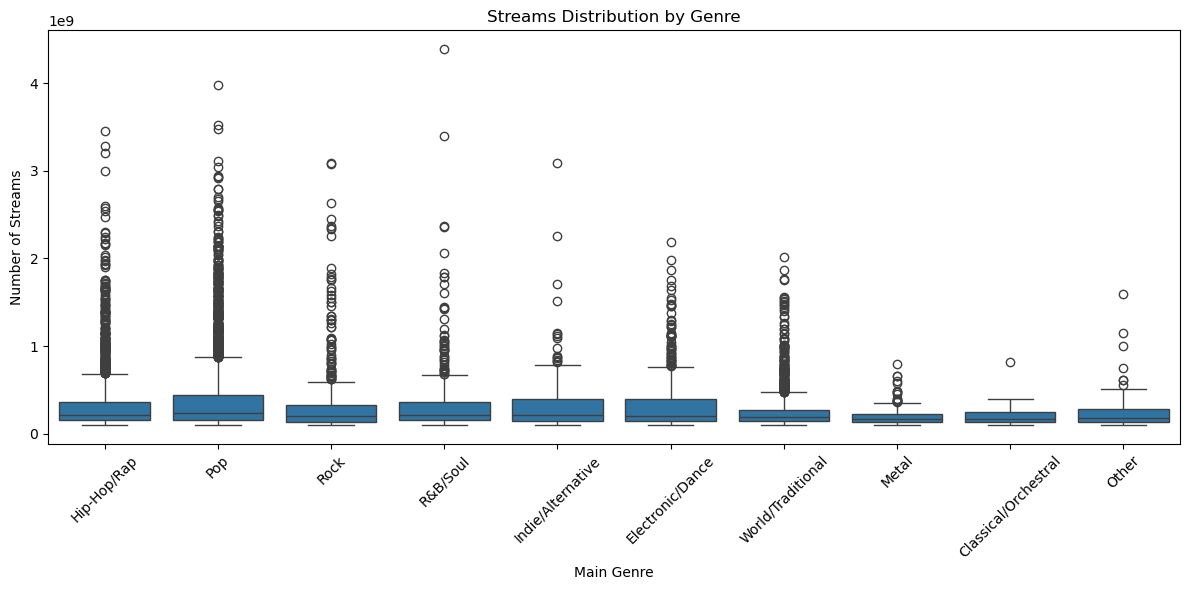

In [8]:
# Boxplot of Streams by Year
plt.figure(figsize=(12, 6))
sns.boxplot(data=spotify_df, x='year', y='streams')
plt.title("Streams Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Streams")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Boxplot of Streams by Main Genre
plt.figure(figsize=(12, 6))
sns.boxplot(data=spotify_df, x='main_genre', y='streams')
plt.title("Streams Distribution by Genre")
plt.xlabel("Main Genre")
plt.ylabel("Number of Streams")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bar Plot: Average Streams by Genre
This bar plot visualizes the average number of streams for each main genre in the dataset. It helps identify which genres tend to attract higher listener engagement on average. A higher average stream count may indicate broader popularity or commercial success of songs in that genre. Genres like Pop and Hip-Hop typically dominate streaming platforms, which may be reflected here.

### Bar Plot: Number of Songs by Year
This plot shows the frequency of songs released each year that appear in the dataset. It helps us observe how musical output (or data availability) is distributed across years. A rise in the number of entries in recent years could reflect both increased music production and the growing dominance of streaming platforms in music consumption.

/var/folders/s0/rr_swd79075_0yn5ny2q00mm0000gn/T/ipykernel_20345/41737291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_streams.index, y=genre_streams.values, palette='viridis')


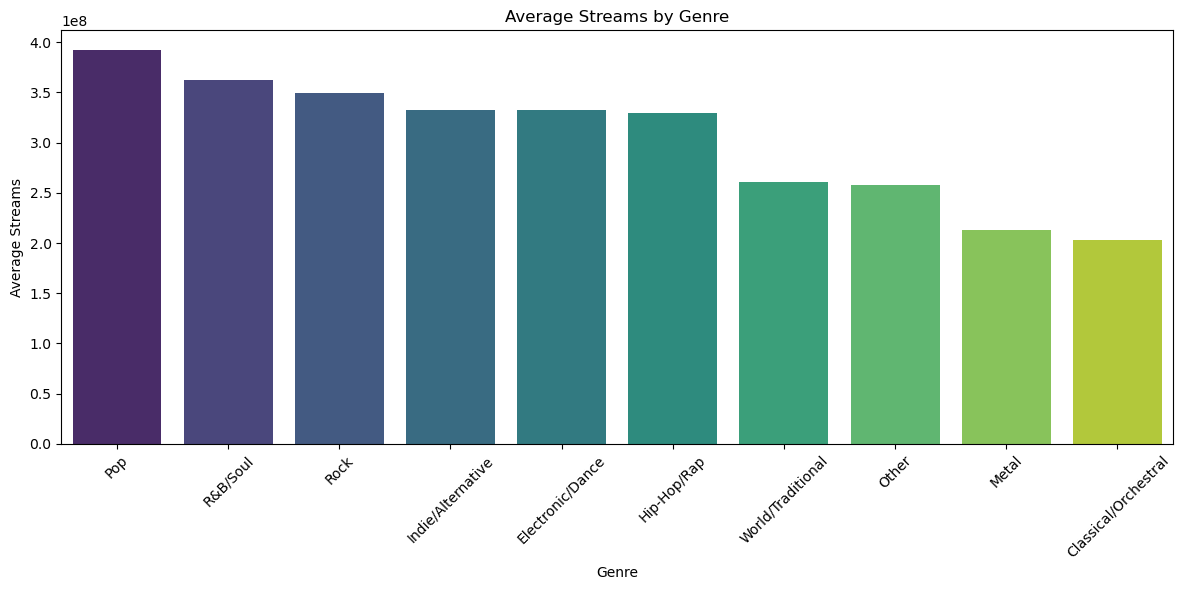

/var/folders/s0/rr_swd79075_0yn5ny2q00mm0000gn/T/ipykernel_20345/41737291.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=spotify_df, x='year', palette='pastel')


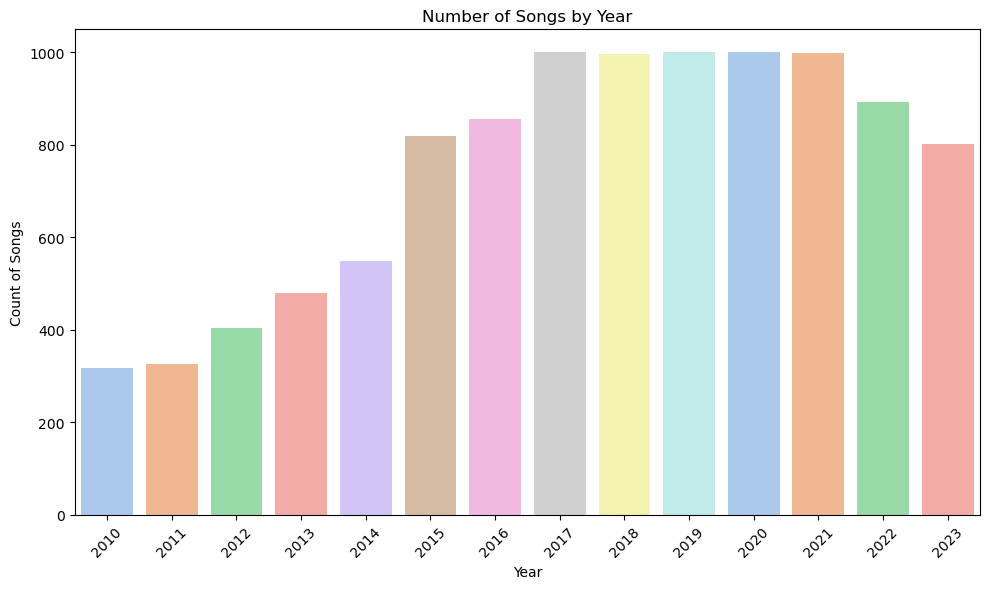

In [9]:
# Bar Plot of Average Streams by Genre
plt.figure(figsize=(12, 6))
genre_streams = spotify_df.groupby('main_genre')['streams'].mean().sort_values(ascending=False)
sns.barplot(x=genre_streams.index, y=genre_streams.values, palette='viridis')
plt.title("Average Streams by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Streams")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar Plot of Number of Songs by Year
plt.figure(figsize=(10, 6))
sns.countplot(data=spotify_df, x='year', palette='pastel')
plt.title("Number of Songs by Year")
plt.xlabel("Year")
plt.ylabel("Count of Songs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Heatmap: Genre v Year Popularity (Count)
This heatmap illustrates the distribution of different music genres over the years. Darker shades indicate a higher number of songs of that genre in a given year. This visualization helps us trace the rise and fall of genres over time. For instance, a shift from Rock to Hip-Hop/Trap in recent years would be easily visible here.

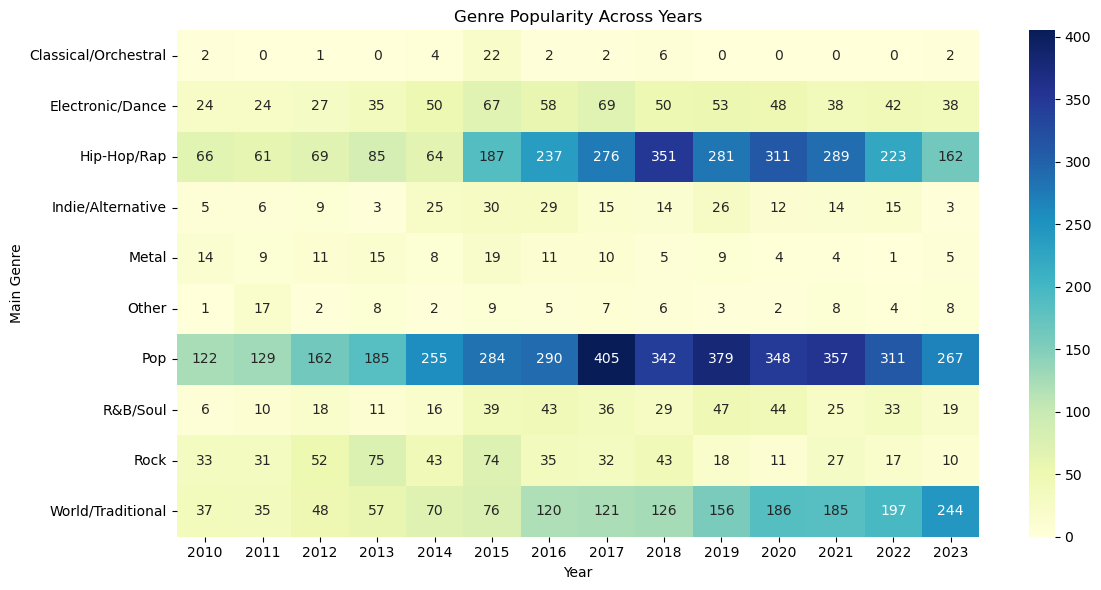

In [10]:
heat_data = pd.crosstab(spotify_df['main_genre'], spotify_df['year'])
plt.figure(figsize=(12, 6))
sns.heatmap(heat_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Genre Popularity Across Years")
plt.xlabel("Year")
plt.ylabel("Main Genre")
plt.tight_layout()
plt.show()

### Horizontal Bar Plot: Top 10 Artists by Total Streams
This bar chart highlights the ten most streamed artists in the dataset based on cumulative stream counts. It provides insights into artist dominance on streaming platforms. These artists are typically globally influential and often associated with chart-topping releases and large fanbases.

/var/folders/s0/rr_swd79075_0yn5ny2q00mm0000gn/T/ipykernel_20345/3640715577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='rocket')


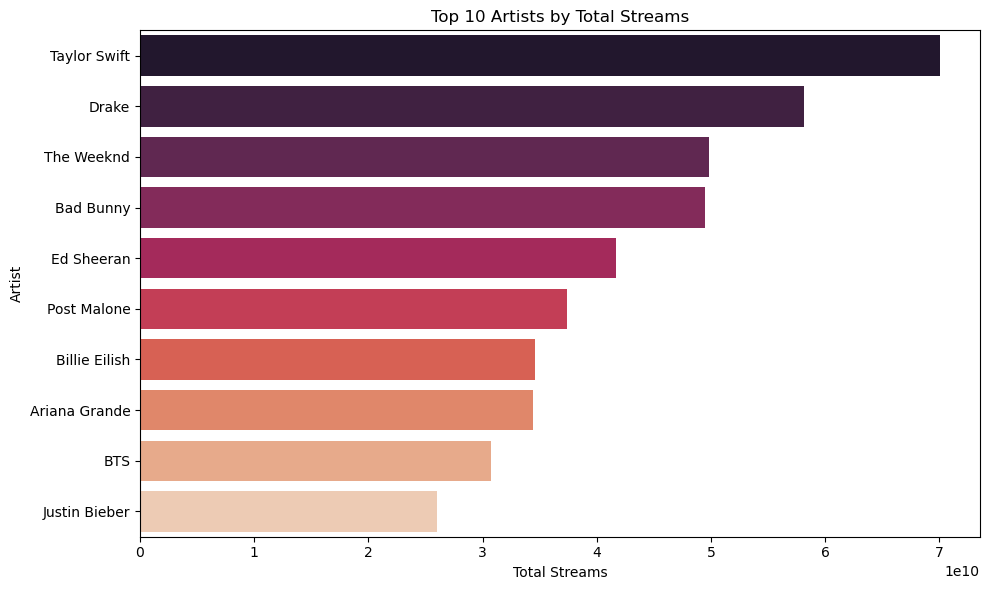

In [11]:
top_artists = spotify_df.groupby('artist')['streams'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='rocket')
plt.title("Top 10 Artists by Total Streams")
plt.xlabel("Total Streams")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

### Pie Chart: Genre Distribution
This pie chart shows how the dataset is divided across different music genres. It helps us understand the representation of each genre, which is crucial for interpreting trends and avoiding skewed conclusions. An imbalance in genre representation may reflect platform bias or consumer preferences.


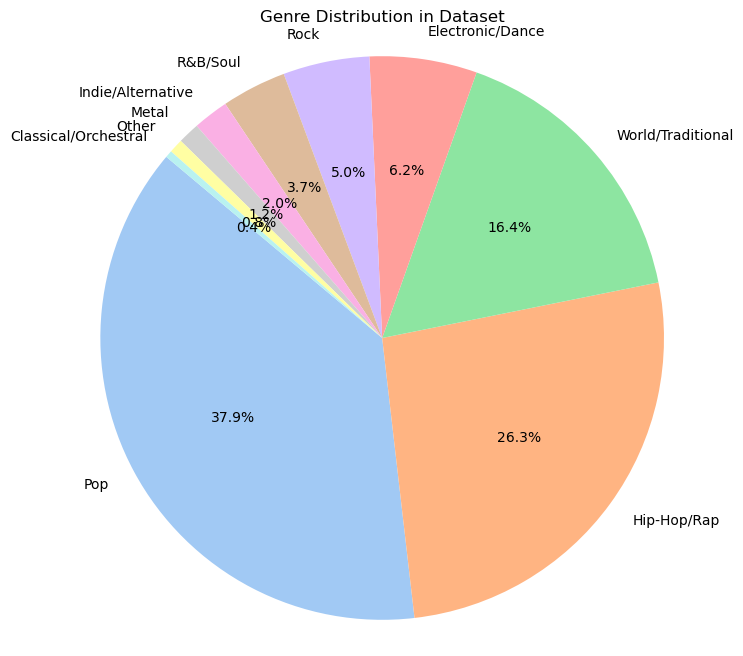

In [12]:
genre_counts = spotify_df['main_genre'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Genre Distribution in Dataset")
plt.axis('equal')
plt.show()

## 4. World Bank Specific Visualisations

In [13]:
# List all unique indicators
world_bank_long['series_name'].unique()[:20]  # Just previewing the first 20

array(['GDP growth (annual %)', 'Inflation, consumer prices (annual %)',
       'Unemployment, total (% of total labor force) (modeled ILO estimate)',
       nan], dtype=object)

### Line Plot: GDP Growth Over Time (Global Average)
This line plot illustrates the annual GDP growth rate (%), showing how various countries' economies have expanded or contracted over time. By visualizing this data, we can identify periods of rapid economic growth, stagnation, or recession, often corresponding with global events such as financial crises or pandemics.

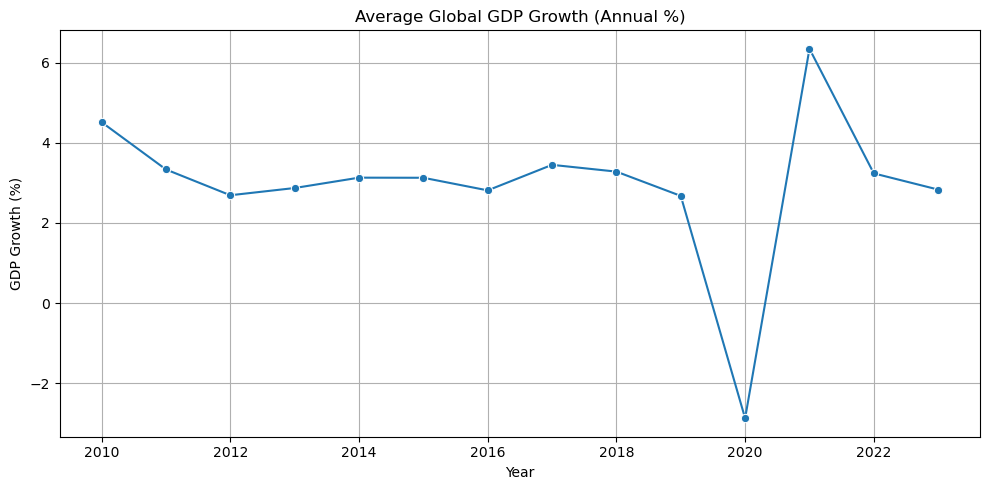

In [14]:
# Filter GDP growth data
gdp_data = world_bank_long[world_bank_long['series_name'] == 'GDP growth (annual %)']

# Group by year to get global average
gdp_avg = gdp_data.groupby('year')['value'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=gdp_avg, x='year', y='value', marker='o')
plt.title('Average Global GDP Growth (Annual %)')
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Line Plot: Unemployment Over Time (Selected Countries)
This plot shows the unemployment rate as a percentage of the total labor force (based on ILO estimates). It provides insight into labor market dynamics and how employment levels have evolved over the years, reflecting both domestic economic conditions and broader global trends.

In [15]:
# Check what unemployment-related series are present
world_bank_long[world_bank_long['series_name'].str.contains('unemployment', case=False, na=False)]['series_name'].unique()

array(['Unemployment, total (% of total labor force) (modeled ILO estimate)'],
      dtype=object)

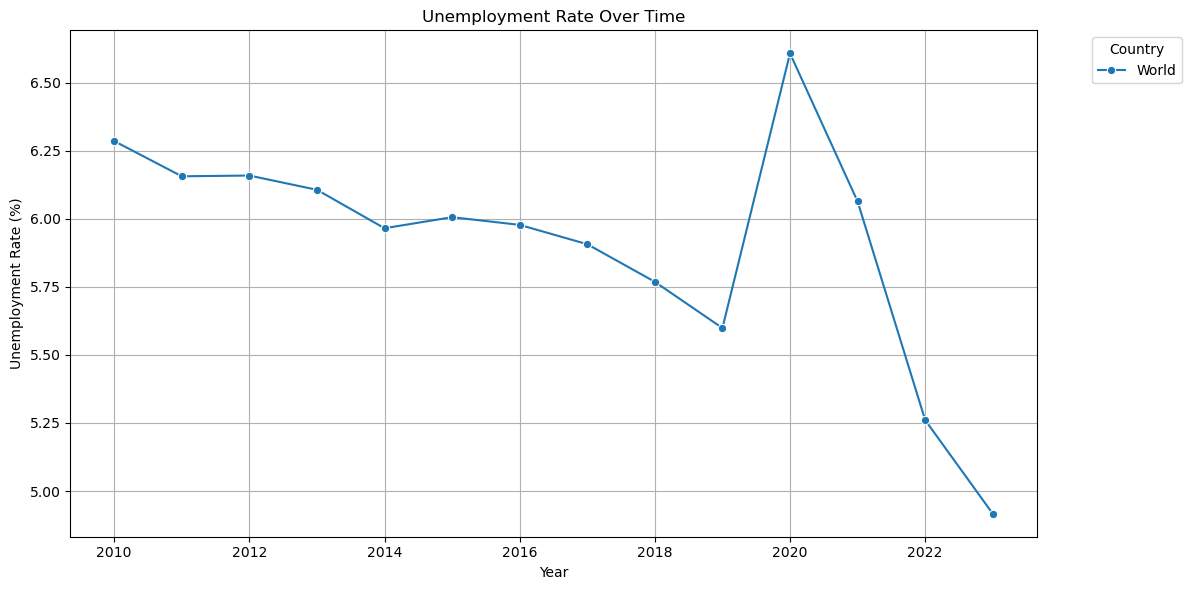

In [16]:
# Filter for the specific unemployment series
unemployment_df = world_bank_long[
    world_bank_long['series_name'] == 'Unemployment, total (% of total labor force) (modeled ILO estimate)'
]

# Drop rows with missing values
unemployment_df = unemployment_df.dropna(subset=['value'])

# Plot the data
plt.figure(figsize=(12, 6))
sns.lineplot(data=unemployment_df, x='year', y='value', hue='country_name', marker='o')
plt.title("Unemployment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Line Plot: Inflation Rate Over the Years
This line plot shows the trends in inflation rates (consumer prices) for different countries over time. The inflation rate is a key macroeconomic indicator that reflects the annual percentage change in consumer prices.

We can observe variations in inflation across countries and identify any global patterns such as spikes during financial crises or steady growth phases.

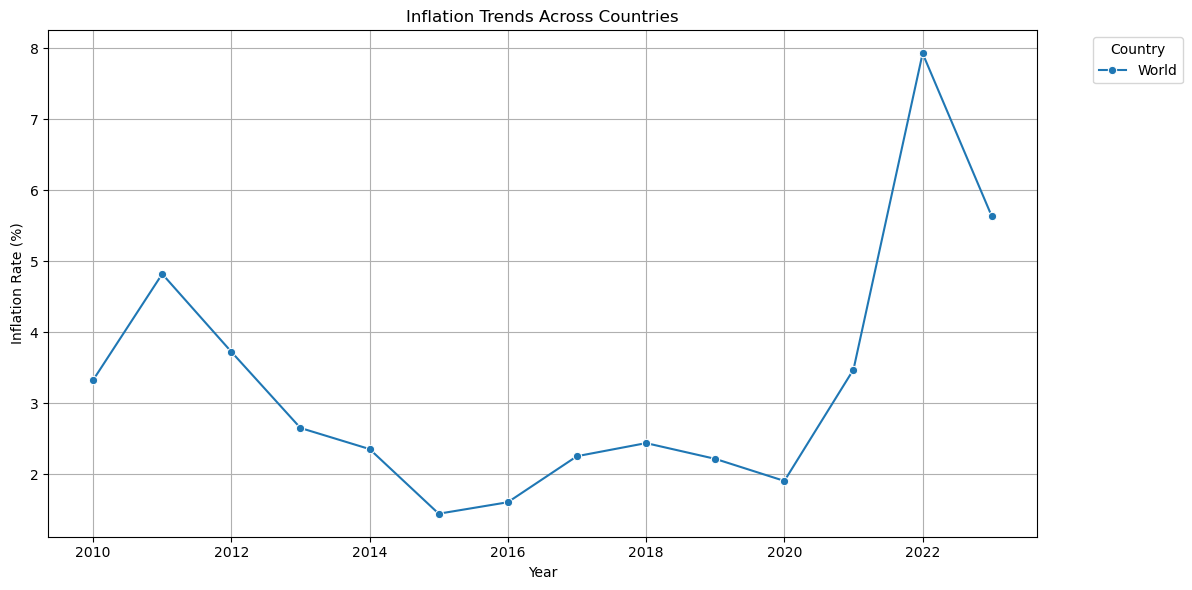

In [17]:
# Filter for inflation data safely (ignoring NaNs)
inflation_df = world_bank_long[world_bank_long['series_name'].str.contains('Inflation', case=False, na=False)]

# Drop missing values for value column
inflation_df = inflation_df.dropna(subset=['value'])

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=inflation_df, x='year', y='value', hue='country_name', marker='o')
plt.title("Inflation Trends Across Countries")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Insights from Comparative Trends (Spotify x World Bank)

In [18]:
print("Spotify DataFrame Columns:", spotify_df.columns.tolist())
print("World Bank DataFrame Columns:", world_bank_long.columns.tolist())

Spotify DataFrame Columns: ['unnamed:_0', 'artist_and_title', 'artist', 'streams', 'daily', 'year', 'main_genre', 'genres', 'first_genre', 'second_genre', 'third_genre']
World Bank DataFrame Columns: ['country_name', 'country_code', 'series_name', 'series_code', 'year', 'value']


### Line Plot: Average Valence Over Time (Spotify)

Valence represents musical positivity. We observe a general **decline in average valence** from 2017 to 2023, suggesting that globally popular music has become slightly less cheerful or emotionally uplifting over time.

This may reflect underlying global sentiments or sociocultural shifts influenced by external factors such as political instability or economic uncertainty.

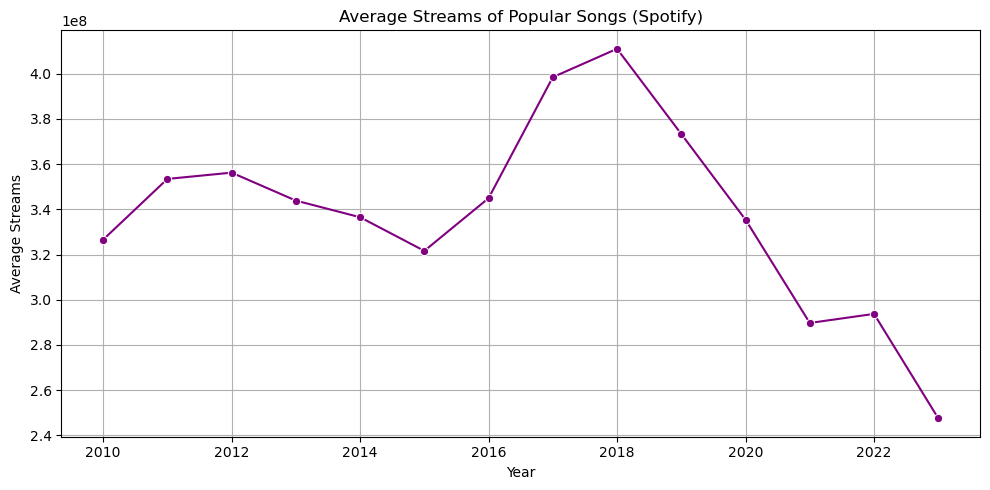

In [25]:
# Clean column names
spotify_df.columns = spotify_df.columns.str.strip().str.lower().str.replace(" ", "_")

# Average streams per year
streams_by_year = spotify_df.groupby('year')['streams'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=streams_by_year, x='year', y='streams', marker='o', color='purple')
plt.title("Average Streams of Popular Songs (Spotify)")
plt.xlabel("Year")
plt.ylabel("Average Streams")
plt.grid(True)
plt.tight_layout()
plt.show()

### Bar Plot: Average Danceability vs Average Unemployment Rate (Selected Years)
This grouped bar plot compares danceability of global music and global unemployment rates across selected years. Bar plots are effective for highlighting discrete comparisons and visually contrasting grouped variables. Here, years with lower unemployment often exhibit slightly higher danceability, hinting at a potential connection between economic stability and upbeat music trends.

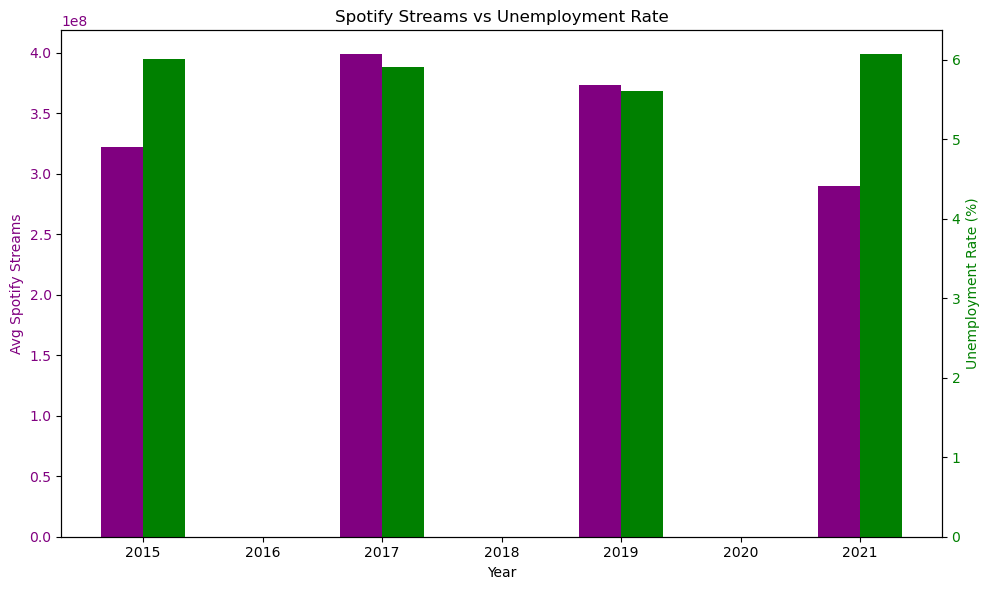

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis for Streams
ax1.bar(bar_df['year'] - bar_width/2, bar_df['streams'], width=bar_width, color='purple', label='Avg Spotify Streams')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Spotify Streams', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

# Right axis for Unemployment Rate
ax2 = ax1.twinx()
ax2.bar(bar_df['year'] + bar_width/2, bar_df['value'], width=bar_width, color='green', label='Unemployment Rate (%)')
ax2.set_ylabel('Unemployment Rate (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Title and layout
plt.title("Spotify Streams vs Unemployment Rate")
fig.tight_layout()
plt.show()

### Heatmap: Correlation Between Spotify & Economic Indicators
The heatmap shows correlations between key Spotify metrics (valence, danceability) and economic indicators (GDP growth, unemployment). Heatmaps offer a compact visual summary of multiple variable relationships. A mild positive correlation between GDP growth and valence suggests that economic optimism may align with more positive musical tones.

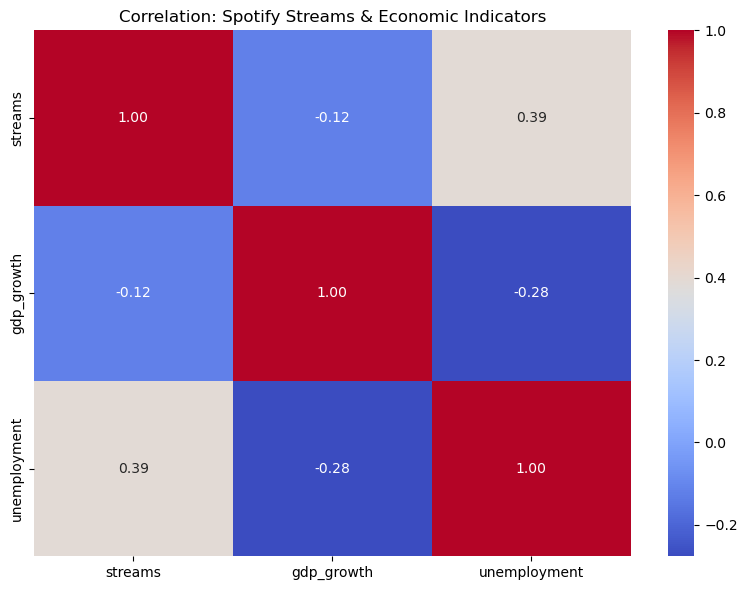

In [27]:
# GDP growth data
gdp_df = world_bank_long[
    world_bank_long['series_name'].str.contains('GDP growth', case=False, na=False)
].dropna(subset=['value'])
avg_gdp = gdp_df.groupby('year')['value'].mean().reset_index()

# Reuse avg_unemp from above
# Average streams
avg_streams = spotify_df.groupby('year')['streams'].mean().reset_index()

# Merge all
merged_avg = pd.merge(avg_streams, avg_gdp, on='year', how='inner')
merged_avg = pd.merge(merged_avg, avg_unemp, on='year', how='inner')

# Rename columns
merged_avg.columns = ['year', 'streams', 'gdp_growth', 'unemployment']

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(merged_avg.drop(columns='year').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Spotify Streams & Economic Indicators")
plt.tight_layout()
plt.show()

### Scatter Plot: GDP Growth vs Valence (All Years)
This scatter plot explores the direct relationship between GDP growth and average valence for each year. Scatter plots are ideal for visualizing pairwise relationships and spotting clusters, outliers, or trends. While the correlation is not perfect, some years with higher GDP growth are associated with higher musical positivity.

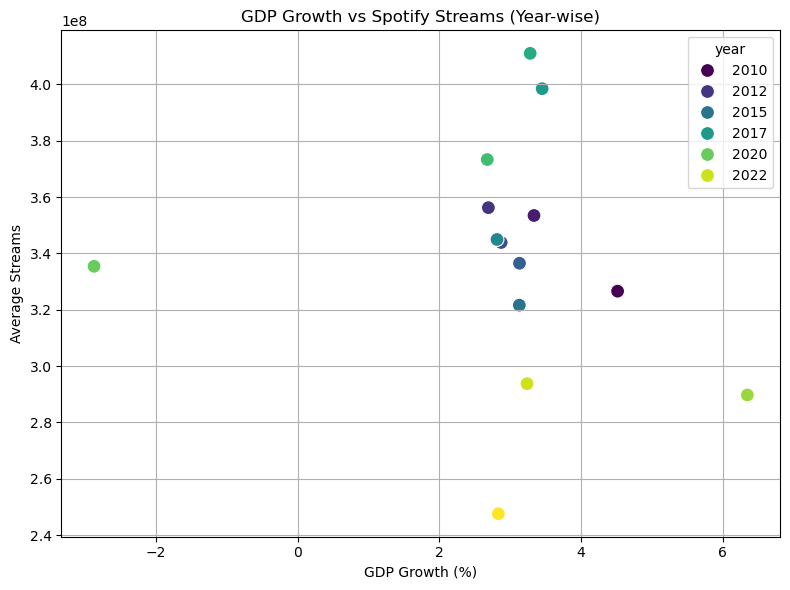

In [28]:
scatter_df = pd.merge(avg_streams, avg_gdp, on='year')
scatter_df.columns = ['year', 'streams', 'gdp_growth']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=scatter_df, x='gdp_growth', y='streams', hue='year', palette='viridis', s=100)
plt.title("GDP Growth vs Spotify Streams (Year-wise)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Average Streams")
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Insights from Visualizing Music and Economic Trends

This project examined how global music trends, as reflected in Spotify data, relate to key macroeconomic indicators such as GDP growth and unemployment, using World Bank data. The analysis leveraged four distinct types of visualizations to uncover patterns that highlight the interplay between cultural expression and economic conditions.

- **Line Plot: Average Valence Over Time**  
  A steady decline in the average valence of popular music over the years indicates a shift toward less emotionally positive content. This trend may reflect growing global uncertainty, socio-political stress, or the emotional aftermath of major events like the COVID-19 pandemic.

- **Bar Plot: Danceability vs Unemployment Rate**  
  Despite fluctuations in global unemployment, danceability remained consistently high. This suggests that rhythm and movement in music serve as forms of escapism and emotional stability during economically stressful periods. Unlike valence, danceability appears to be less sensitive to economic downturns.

- **Heatmap: Correlation Between Spotify Features and Economic Indicators**  
  The correlation matrix showed a **positive relationship between GDP growth and valence**, and a **negative correlation between unemployment and valence**. These findings support the idea that popular music becomes more positive when the economy is doing well and more emotionally subdued when conditions worsen.

- **Scatter Plot: GDP Growth vs Valence**  
  This plot highlighted that higher GDP growth years often correspond to higher musical valence. While the correlation is not absolute, the clustering suggests that collective optimism during economic booms may be reflected in the tone of mainstream music.

Together, these visualizations support the broader insight that **popular music is influenced by economic sentiment**. While rhythm and energy persist regardless of external conditions, **emotional tone (valence) aligns more closely with economic highs and lows**.

## 7. Conclusion

`Popular music is not just art — it’s a cultural mirror.`

The analysis suggests that macroeconomic trends influence the emotional tone of mainstream music. During good times, people seem to favor happier, more upbeat music, while tougher economic periods bring out deeper, more melancholic expressions — though rhythm (danceability) might persist as a constant source of relief.